# Classification

One of the first approaches we have to understand is that our ability to make predictions goes beyond unsupervised learning methods.
For instance, we may be interested in predicting if materials are toxic or non-toxic (categorical labels $\rightarrow$ classification) or what are the free energies of something (quantitative labels $\rightarrow$ regression).

In this notebook, we will use a **supervised learning** method to classify between different labels, using the results shown in the previous examples.

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install dscribe
    !pip install umap-learn
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/05-BasicLearning"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

# ase is the package we use to read files related to atomistic structures
from ase import Atoms
from ase.io import read

# we will import the dimensionality reduction and clustering algorithms as well
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

# dscribe is one package that is widely used for featurization of atomistic structures
from dscribe.descriptors import SOAP

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## Building intuition with a sample dataset

In this notebook, we will first build our intuition for a classifier by using the periodic table dataset and performing a two-class classification.
To do so, we will start with our periodic table dataset, and cast "metalloids" as non-metals in the labels:

In [3]:
pt = pd.read_csv(f"{ROOT}/data/ptable.csv")
df = pt.loc[
    (~pt["Electronegativity"].isna())
    & (~pt["FirstIonization"].isna())
    & (~pt["Density"].isna())
]
idx = (df["MetallicProperty"] == "metalloid")
df.loc[idx, "MetallicProperty"] = "nonmetal"

As an example, here is the number of elements per property:

In [4]:
df.groupby("MetallicProperty").count()["Element"]

MetallicProperty
metal       74
nonmetal    19
Name: Element, dtype: int64

In principle, we could simply analyze the data using violin plots:

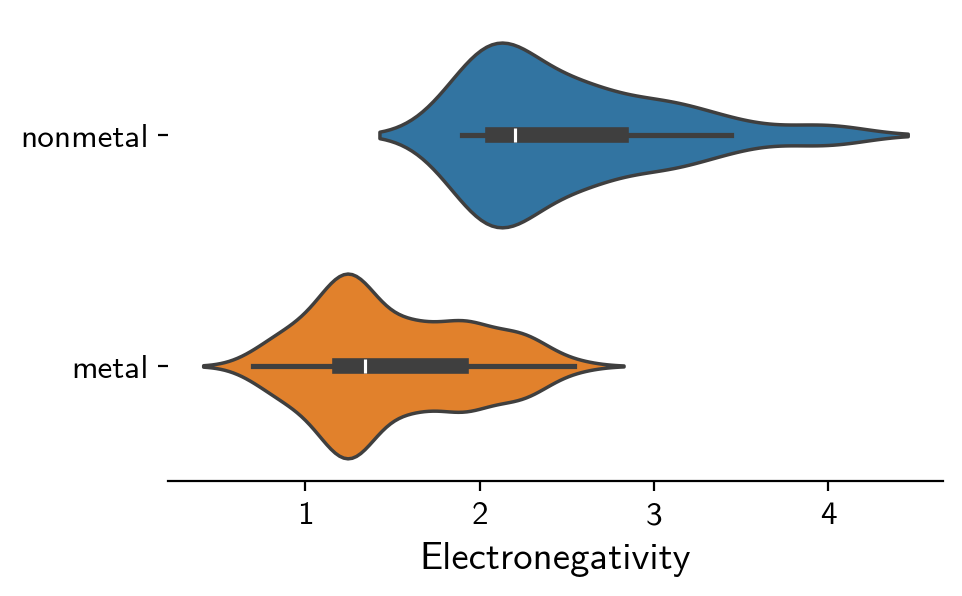

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.violinplot(
    df,
    x="Electronegativity",
    y="MetallicProperty",
    hue="MetallicProperty",
    bw_adjust=0.75,
    ax=ax,
)

ax.set_ylabel("")
ax.spines["left"].set_visible(False)

### Preparing and fitting a model

What we will do next is to move away from visualizations only, to fitting a model that is much more agnostic to the variables themselves.

In [6]:
# Prepare features (X) and labels (y)
label = "MetallicProperty"
encoder = OrdinalEncoder()

# For initial model, use only electronegativity as feature
X = df["Electronegativity"].values.reshape(-1, 1)

# Convert categorical labels to numeric values (1: nonmetal, 0: metal)
y = encoder.fit_transform(df[label].values.reshape(-1, 1)).astype(int).reshape(-1)

print(X.shape, y.shape)

(93, 1) (93,)


Let's use this dataset to create train/test sizes with a ratio of 80:20:

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

print(X_train.shape, X_test.shape)

(74, 1) (19, 1)


Finally, let's train the model using the `fit` method in `scikit-learn`:

In [8]:
# Train logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(y_pred_test)
print(y_test)

[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]


Once we have the model, we can evaluate its performance:

In [9]:
# Calculate and display metrics
print("\nModel Performance:")
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_pred_train):.3f}")
print(f"Test accuracy: {metrics.accuracy_score(y_test, y_pred_test):.3f}")


Model Performance:
Training accuracy: 0.892
Test accuracy: 0.842


The performance looks amazing!
Before we get too excited, it may be relevant for us to get more realistic with our metrics.
For example, what is a reasonable baseline? One could argue that predicting that an element is a metal is better than predicting that it is a non-metal. Let's quantify that:

In [10]:
# Compare with baseline (always predicting the majority class, which is 0)
baseline_acc = metrics.accuracy_score(y_test, np.zeros_like(y_test))
print(f"Baseline accuracy (always predict metal): {baseline_acc:.3f}")

Baseline accuracy (always predict metal): 0.895


Well, now we see that the performance is not that extraordinary given the baseline.
It is still superior to the baseline, though!

### Interpreting the model

Now that the model is trained, it is useful for us to visualize its decision boundary (i.e., the logistic regression curve).

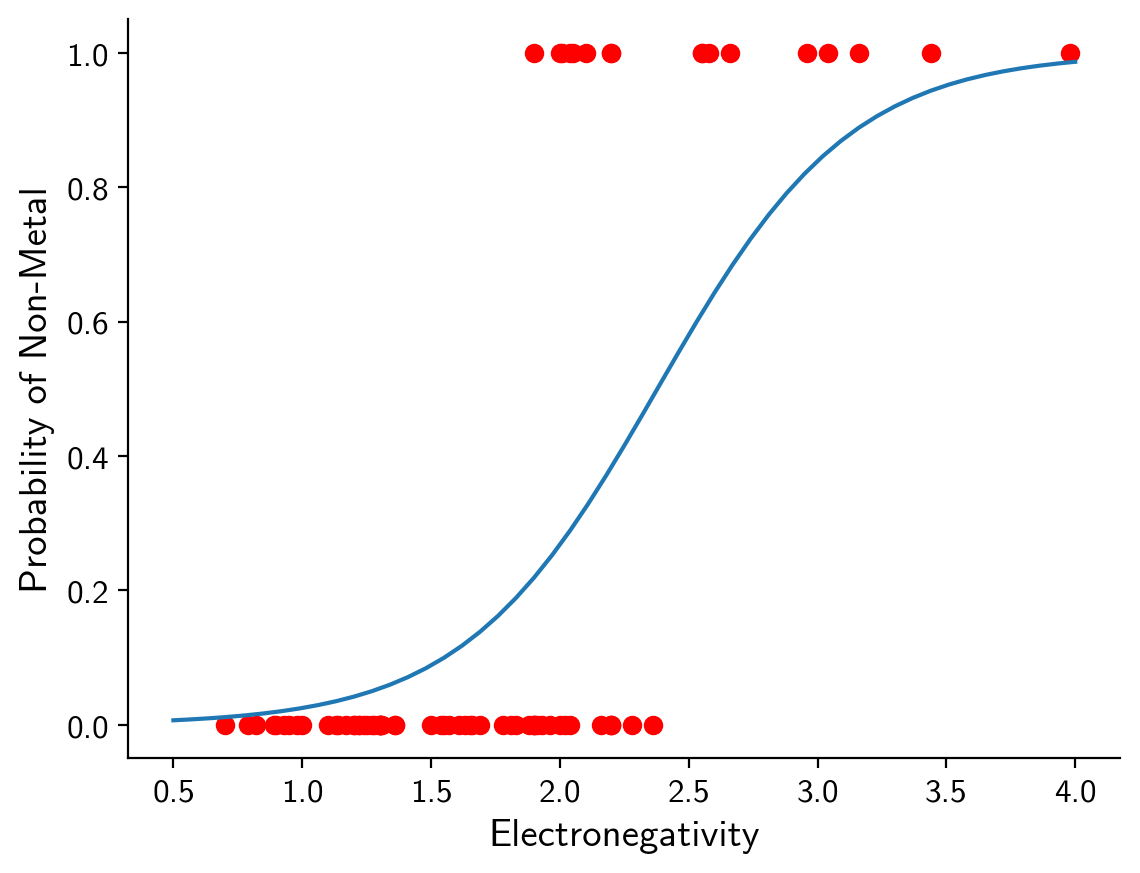

In [11]:
X_space = np.linspace(0.5, 4, 51).reshape(-1, 1)
decision = model.predict_proba(X_space)[:, 1]

fig, ax = plt.subplots()
ax.plot(X_space, decision, label="Decision Boundary")
ax.scatter(X_train, y_train, c="r", label="Training Data")
ax.set_xlabel("Electronegativity")
ax.set_ylabel("Probability of Non-Metal")

plt.show()

This result shows how a single feature (electronegativity) makes it hard to predict whether something is a metal or not.

## Fitting a classifier over more than a feature

Using a single, one-dimensional feature is good because it is simple.
However, in most cases, you will need a representation that is very high dimensional.
Therefore, it is useful to know how to perform classification over multiple features.
Let's do that here.
Let's first see how a possible 2D representation could look like when we predict that a material a metal or not:

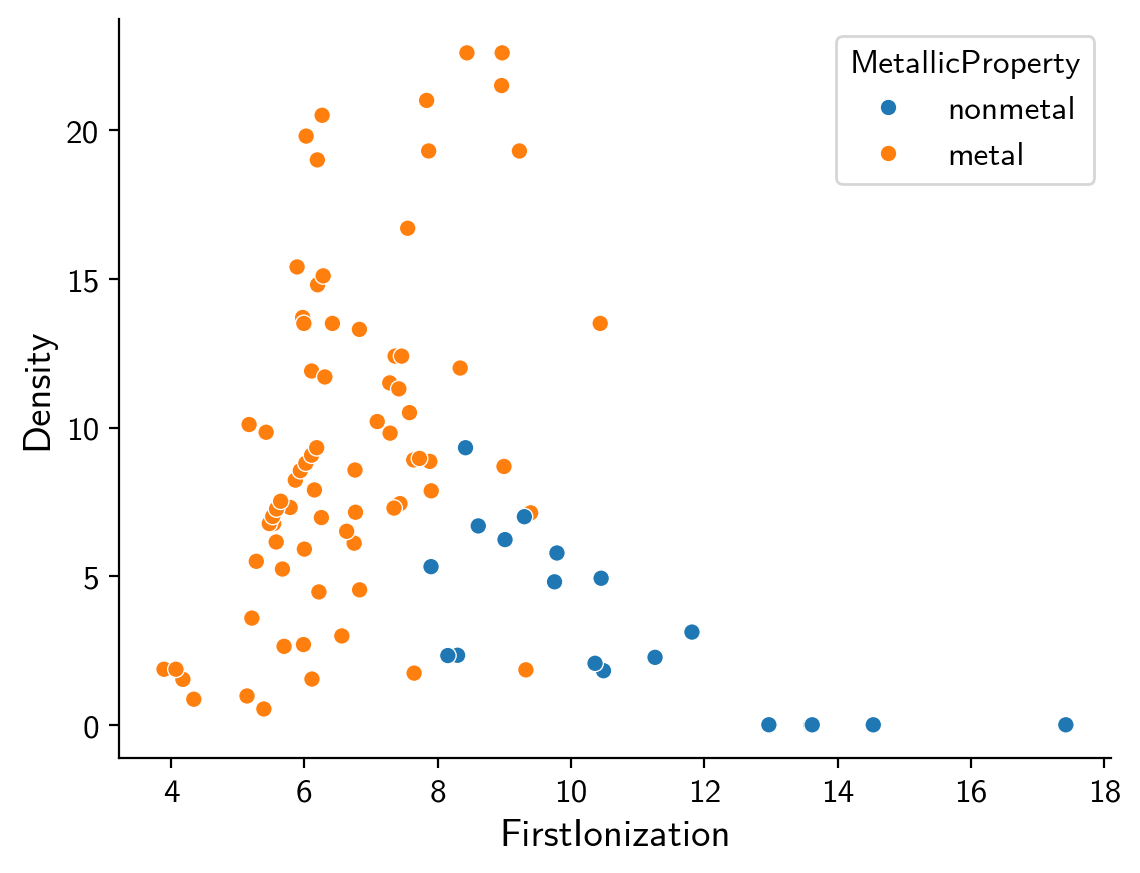

In [12]:
sns.scatterplot(
    data=df,
    x="FirstIonization",
    y="Density",
    hue="MetallicProperty"
)

plt.show()

The plot above shows that the first ionization energy and the density can be useful features.
Let's use them and normalize them. The normalization is useful to standardize them; otherwise, one will have a higher importance compared to the other.

In [13]:
# Prepare 2D feature set
X_2d = df[["FirstIonization", "Density"]].values

# Scale the first ionization to be in a similar range as electronegativity
scaler = StandardScaler()
X_2d = scaler.fit_transform(X_2d)

# Split the 2D data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.20, random_state=65
)

# Train a new model with 2D features
model_2d = LogisticRegression(random_state=57)
model_2d.fit(X_train_2d, y_train_2d)

# Make predictions
y_pred_train_2d = model_2d.predict(X_train_2d)
y_pred_test_2d = model_2d.predict(X_test_2d)

# Compare performance
print("\n2D Model Performance:")
print(f"Training accuracy: {metrics.accuracy_score(y_train_2d, y_pred_train_2d):.3f}")
print(f"Test accuracy: {metrics.accuracy_score(y_test_2d, y_pred_test_2d):.3f}")


2D Model Performance:
Training accuracy: 0.905
Test accuracy: 0.947


Again, the results are very good, and even better than before.
This shows that adding features can help resolve the space for classification, making predictions more refined and more accurate.

### Interpreting the model

Just like we did the interpretation of the model for the 1D example, we can do the same for the 2D:

In [14]:
ioni = np.linspace(4, 18, 51).reshape(-1, 1)
dens = np.linspace(0, 25, 51).reshape(-1, 1)

xx, yy = np.meshgrid(ioni, dens)
inputs = np.column_stack([xx.reshape(-1), yy.reshape(-1)])
inputs = scaler.transform(inputs)
boundary = model_2d.predict_proba(inputs)[:, 1].reshape(xx.shape)

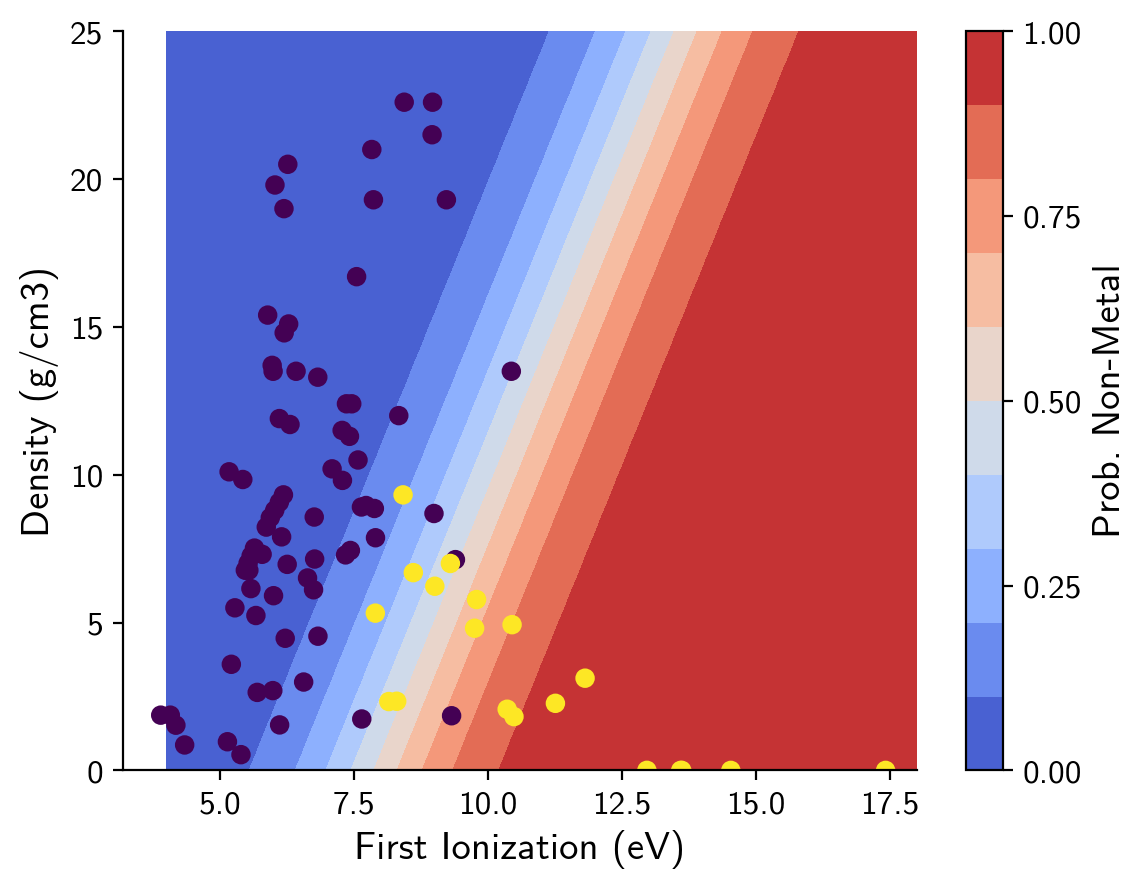

In [15]:
fig, ax = plt.subplots()

levels = np.arange(0, 1.01, 0.1)
norm = plt.Normalize(0, 1)

sc = ax.contourf(xx, yy, boundary, levels=levels, cmap="coolwarm", norm=norm)

cbar = fig.colorbar(sc)
cbar.set_label("Prob. Non-Metal")
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

_x = scaler.inverse_transform(X_2d)
ax.scatter(_x[:, 0], _x[:, 1], c=y)

ax.set_xlabel("First Ionization (eV)")
ax.set_ylabel("Density (g/cm3)")

plt.show()

## Performance Metrics

Our models seem to be performing well according to their accuracy.
Accuracy is not everything, however.
Remember how predicting that everything is a metal has good accuracy, but is certainly not a good model?
Let's evaluate our models using various classification metrics beyond accuracy.

1. **Confusion Matrix**: Shows true positives, false positives, true negatives, and false negatives

2. **Precision**: Accuracy of positive predictions. A high precision means low false positive rate. It is important when false positives are costly

3. **Recall**: Ability to find all positive instances. High recall means low false negative rate. Important when missing positives is costly

4. **F1-Score**: Harmonic mean of precision and recall. Balanced measure when classes are imbalanced.

5. **ROC-AUC**: Model's ability to distinguish between classes. 1.0 means perfect classification, 0.5 means random guessing. Useful for comparing different models

In [16]:
# Calculate and display classification report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred_test))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91        17
           1       0.00      0.00      0.00         2

    accuracy                           0.84        19
   macro avg       0.44      0.47      0.46        19
weighted avg       0.80      0.84      0.82        19



Do you see how the accuracy is high and the average is high, but the recall is not? Let's plot the so-called confusion matrix to describe this fact:

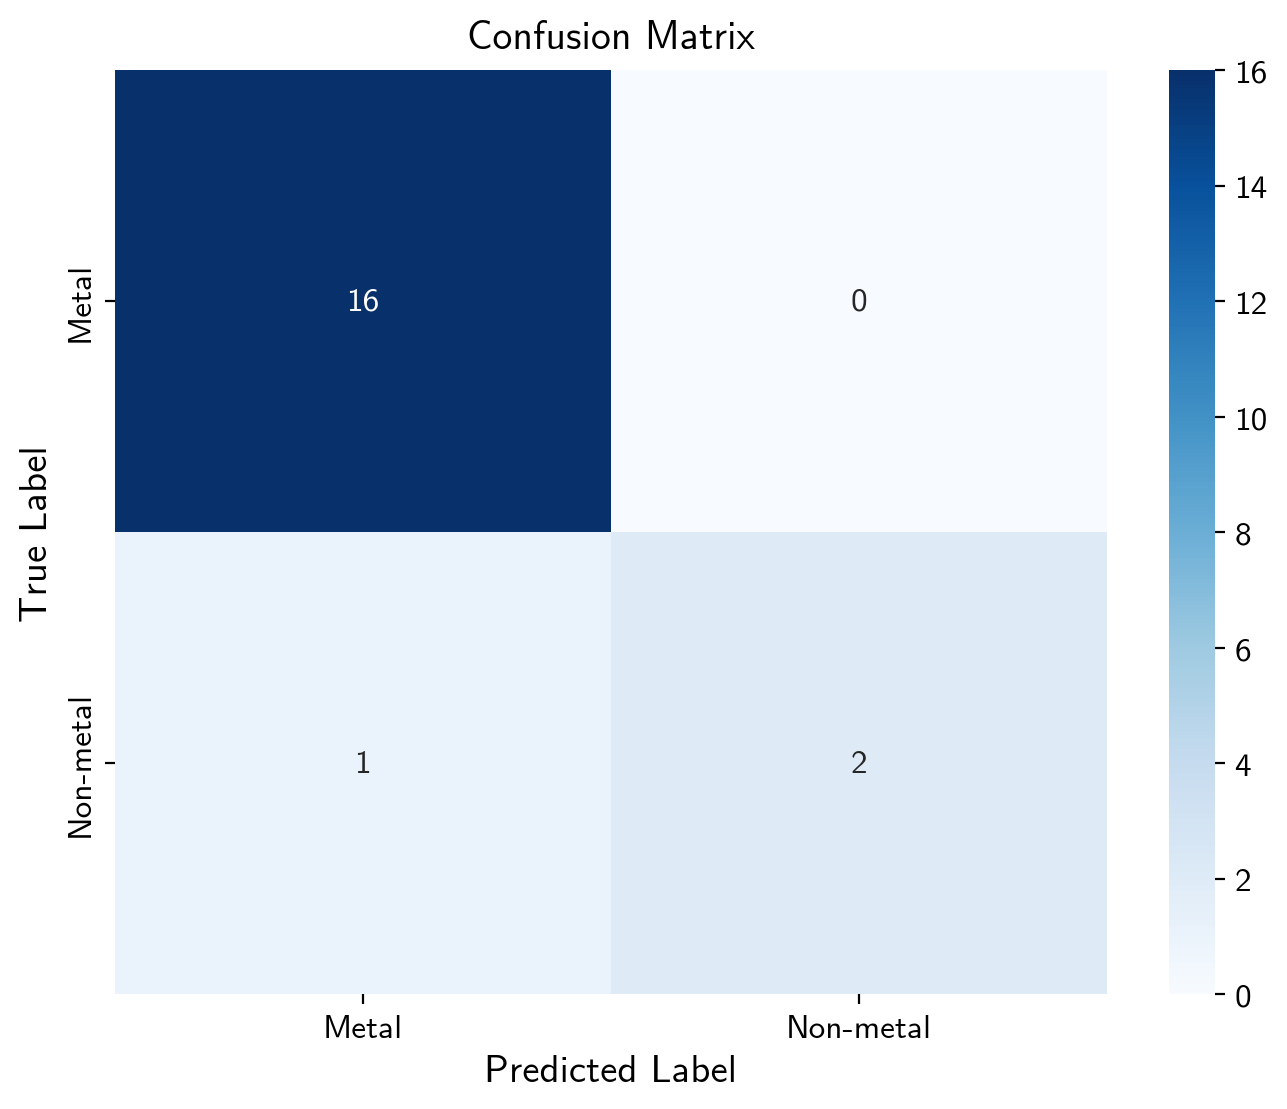

In [17]:
cm = metrics.confusion_matrix(y_test_2d, y_pred_test_2d)
classes = ["Metal", "Non-metal"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", 
    xticklabels=classes, yticklabels=classes,
    ax=ax
)
ax.set_title("Confusion Matrix")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.show()

Alternatively, we can plot the receiver operating characteristic curve for the 1D model:

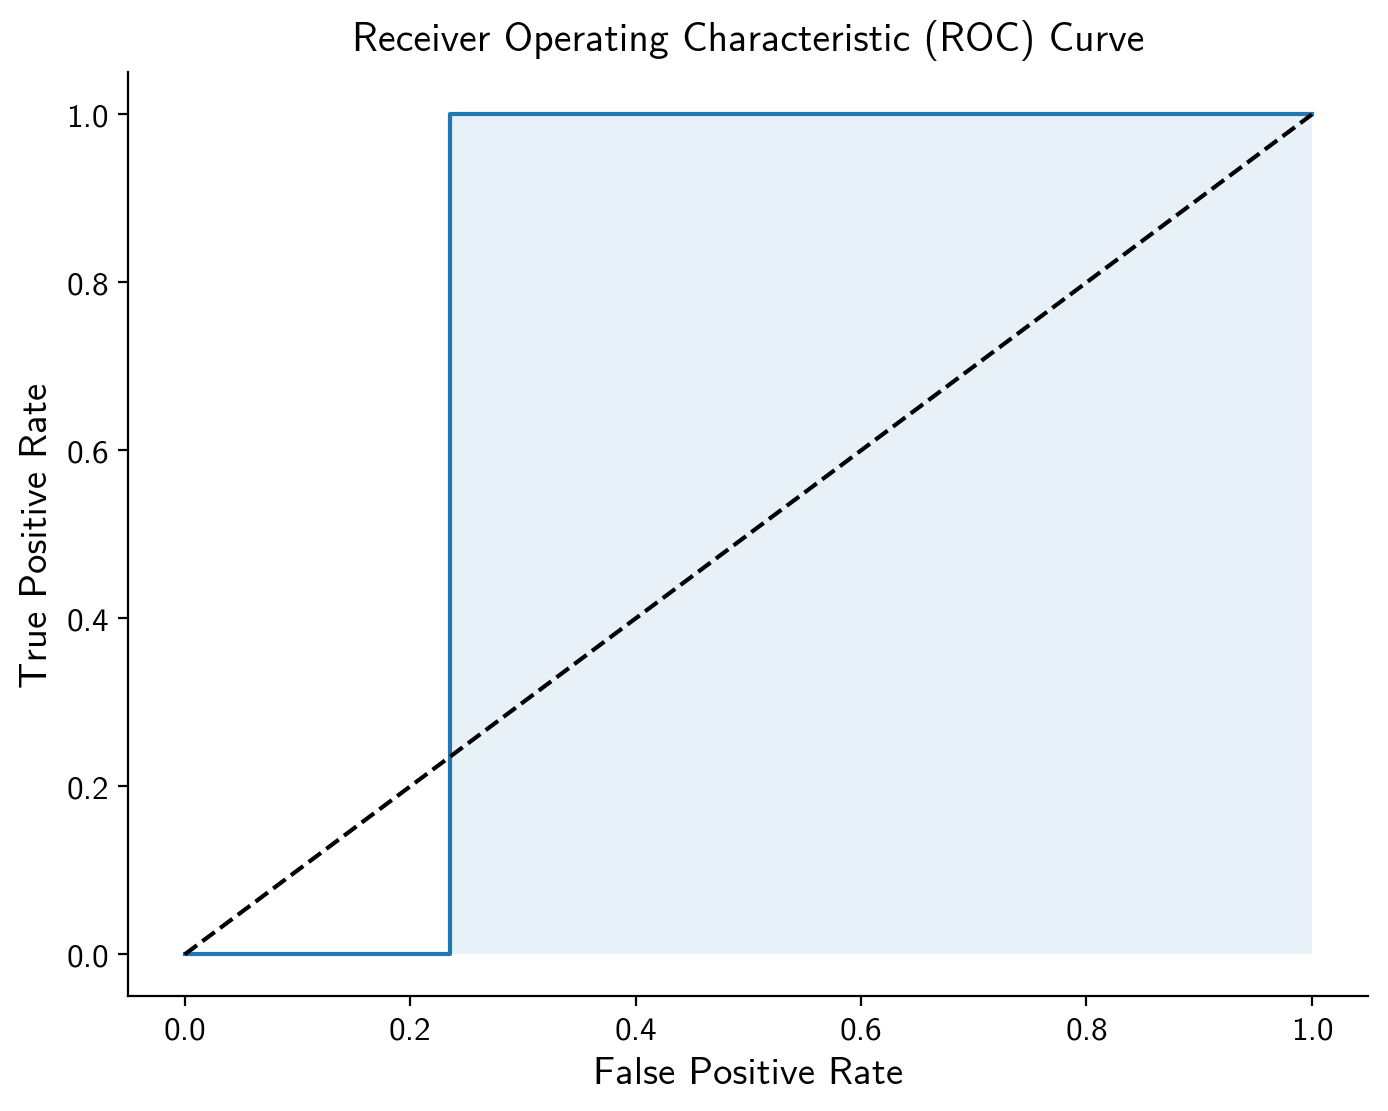

In [18]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")


plt.show()

## Handling Class Imbalance

One problem with our dataset is that it has an imbalance: 74 metals vs 19 non-metals.
In this case, predicting that something is a metal is an unfair advantage that biases the model towards predicting metals.
To address that, we can create **balanced training sets** and compare their performance with the previous models.

In [19]:
def create_balanced_dataset(X, y, random_state=17):
    """Create balanced dataset by downsampling majority class"""
    # Find minority class size
    unique, counts = np.unique(y, return_counts=True)
    min_class_size = min(counts)

    # Split data by class
    X_metal = X[y == 0]
    X_nonmetal = X[y == 1]
    y_metal = y[y == 0]
    y_nonmetal = y[y == 1]

    # Randomly sample from majority class (metals)
    np.random.seed(random_state)
    metal_indices = np.random.choice(len(X_metal), min_class_size, replace=False)

    # Combine balanced datasets
    X_balanced = np.vstack([X_metal[metal_indices], X_nonmetal])
    y_balanced = np.hstack([y_metal[metal_indices], y_nonmetal])

    return X_balanced, y_balanced

In [20]:
# Create balanced datasets for both 1D and 2D features
X_balanced, y_balanced = create_balanced_dataset(X, y)
X_balanced_2d, y_balanced_2d = create_balanced_dataset(X_2d, y)

print(f"Num. non-metals: {(y_balanced == 1).sum()}")
print(f"Num. metals: {(y_balanced == 0).sum()}")

Num. non-metals: 19
Num. metals: 19


Now we can train the model on the balanced dataset (even though it is smaller!)

In [21]:
# Train models on balanced data
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.20, random_state=49
)

X_train_bal_2d, X_test_bal_2d, y_train_bal_2d, y_test_bal_2d = train_test_split(
    X_balanced_2d, y_balanced_2d, test_size=0.20, random_state=56
)

# Train balanced models
model_balanced = LogisticRegression(random_state=33)
model_balanced.fit(X_train_bal, y_train_bal)

model_balanced_2d = LogisticRegression(random_state=25)
model_balanced_2d.fit(X_train_bal_2d, y_train_bal_2d)

LogisticRegression(random_state=25)

In [22]:
# Compare performance
print("\nModel Performance with Balanced Data:")
print("\n1D Balanced Model:")
y_pred_bal = model_balanced.predict(X_test_bal)
print(metrics.classification_report(y_test_bal, y_pred_bal))

print("\n2D Balanced Model:")
y_pred_bal_2d = model_balanced_2d.predict(X_test_bal_2d)
print(metrics.classification_report(y_test_bal_2d, y_pred_bal_2d))


Model Performance with Balanced Data:

1D Balanced Model:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.75      1.00      0.86         3

    accuracy                           0.88         8
   macro avg       0.88      0.90      0.87         8
weighted avg       0.91      0.88      0.88         8


2D Balanced Model:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.80      0.89         5

    accuracy                           0.88         8
   macro avg       0.88      0.90      0.87         8
weighted avg       0.91      0.88      0.88         8



Do you see how the precision is worse, but the recall is much better now?

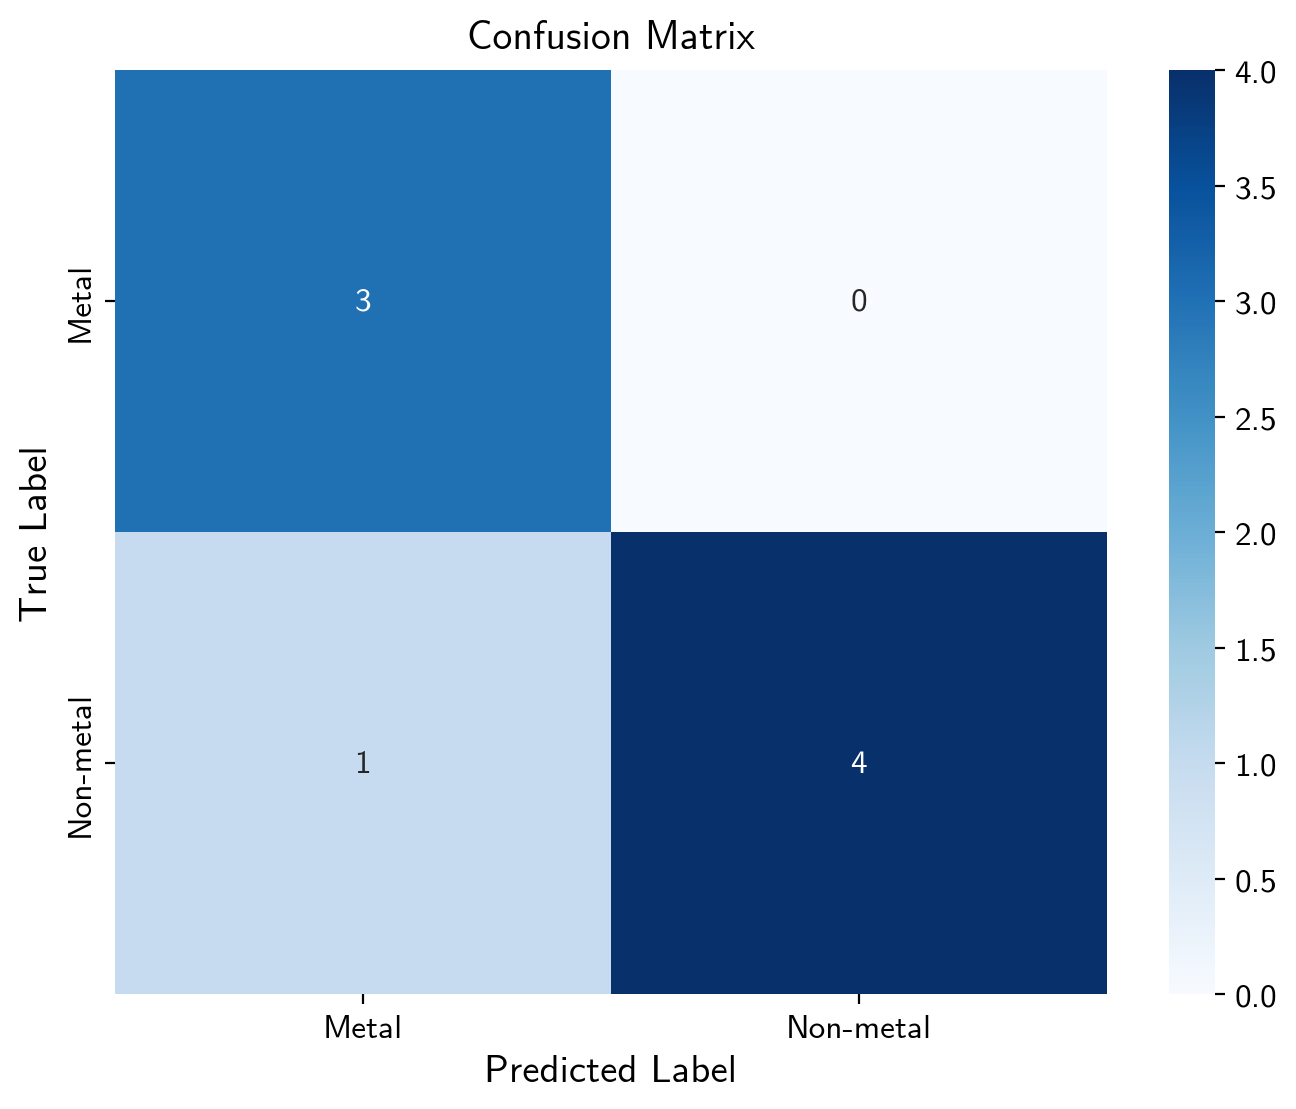

In [23]:
cm = metrics.confusion_matrix(y_test_bal_2d, y_pred_bal_2d)
classes = ["Metal", "Non-metal"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", 
    xticklabels=classes, yticklabels=classes,
    ax=ax
)
ax.set_title("Confusion Matrix")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.show()